A/B Test Analysis: Should we roll out ads to all users?
Business question: Marketing ran an A/B test showing either a real ad (ad) or a public service announcement (psa, the control) to ~588K users. Here we'll see whether the lift is real, whether it's big enough to matter commercially, and who to target if we scale it up.

This notebook answers four questions:

1. Does showing ads increase conversion, and by how much (with uncertainty)?
2. Is that lift big enough to be worth the ad spend?
3. Are there day/hour/frequency segments where the lift is much bigger or smaller?
4. What's the concrete recommendation?

In [26]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [3]:
#loading data

df = pd.read_csv('marketing_AB.csv')
df

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [6]:
#Understanding data

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (588101, 7)

Data types:
Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

Missing values:
Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [8]:
#Cleaning data

df.drop(columns = ['Unnamed: 0', 'user id'], inplace = True)
df

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14
...,...,...,...,...,...
588096,ad,False,1,Tuesday,23
588097,ad,False,1,Tuesday,23
588098,ad,False,3,Tuesday,23
588099,ad,False,1,Tuesday,23


In [10]:
df.head(10)

,test group,converted,total ads,most ads day,most ads hour
0,ad,False,130,Monday,20
1,ad,False,93,Tuesday,22
2,ad,False,21,Tuesday,18
3,ad,False,355,Tuesday,10
4,ad,False,276,Friday,14
5,ad,False,734,Saturday,10
6,ad,False,264,Wednesday,13
7,ad,False,17,Sunday,18
8,ad,False,21,Tuesday,19
9,ad,False,142,Monday,14


In [12]:
#unique values in categorical columns
print("Test Group:", df['test group'].unique())
print("Most Ads Day:", df['most ads day'].unique())
print("Converted:", df['converted'].unique())

Test Group: ['ad' 'psa']
Most Ads Day: ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']
Converted: [False  True]


In [15]:
#See number of users in each group
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

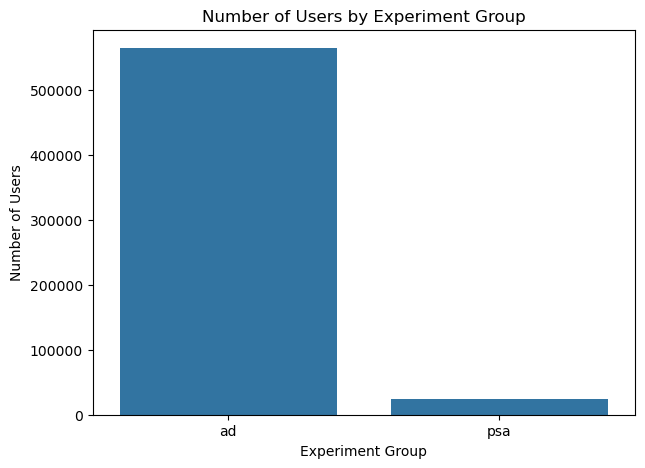

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="test group"
)

plt.title("Number of Users by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Number of Users")

plt.show()

In [18]:
#Converting 'converted' column dtype 

df["converted"] = df["converted"].astype(int)
df["converted"].value_counts()

converted
0    573258
1     14843
Name: count, dtype: int64

In [20]:
pd.crosstab(df["test group"], df["converted"])

converted,0,1
test group,,
ad,550154,14423
psa,23104,420


• 550,154: People in the ad group who did not convert.
• 14,423: People in the ad group who did convert.
• 23,104: People in the psa group who did not convert.
• 420: People in the psa group who did convert.

In [24]:
conversion_summary = (
    df.groupby("test group")["converted"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

conversion_summary.columns = [
    "Group",
    "Users",
    "Conversions",
    "Conversion Rate"
]

conversion_summary["Conversion Rate"] = (
    conversion_summary["Conversion Rate"] * 100
)

conversion_summary

,Group,Users,Conversions,Conversion Rate
0,ad,564577,14423,2.554656
1,psa,23524,420,1.785411


Ad Group:  14,423 conversions out of 564,577 users (2.55%)
PSA Group: 420 conversions out of 23,524 users (1.79%)
The Ad group beat the PSA group by 0.77 percentage points

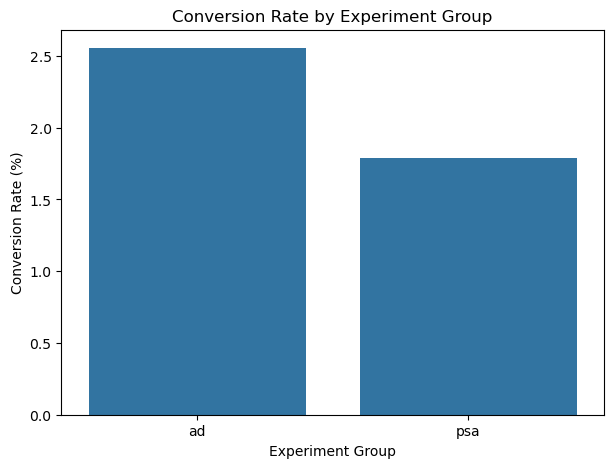

In [25]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=conversion_summary,
    x="Group",
    y="Conversion Rate"
)

plt.title("Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate (%)")

plt.show()

## Does the Ad Actually Lift Conversion?
For a binary conversion outcome, a two-proportion z-test is the more standard and more interpretable choice 
it lets us report a confidence interval on the lift itself, not just a p-value. 
With 588K rows, almost any difference will be 'statistically significant,' 
so the interval on the size of the effect is what actually matters for a rollout decision.

In [43]:
ad = df[df['test group'] == 'ad']['converted']
psa = df[df['test group'] == 'psa']['converted']

count = np.array([ad.sum(), psa.sum()])
nobs = np.array([len(ad), len(psa)])

z_stat, p_val = proportions_ztest(count, nobs)

rate_ad = ad.mean()
rate_psa = psa.mean()
abs_lift = rate_ad - rate_psa
rel_lift = abs_lift / rate_psa * 100

ci_ad = proportion_confint(count[0], nobs[0], method='wilson')
ci_psa = proportion_confint(count[1], nobs[1], method='wilson')

# 95% CI on the difference in proportions (normal approximation)
se_diff = np.sqrt(rate_ad * (1 - rate_ad) / nobs[0] + rate_psa * (1 - rate_psa) / nobs[1])
ci_diff = (abs_lift - 1.96 * se_diff, abs_lift + 1.96 * se_diff)

print(f"Conversion rate — ad:  {rate_ad:.4%}  (95% CI {ci_ad[0]:.4%} to {ci_ad[1]:.4%})")
print(f"Conversion rate — psa: {rate_psa:.4%}  (95% CI {ci_psa[0]:.4%} to {ci_psa[1]:.4%})")
print(f"\nAbsolute lift: {abs_lift:.4%}  (95% CI {ci_diff[0]:.4%} to {ci_diff[1]:.4%})")
print(f"Relative lift: {rel_lift:.2f}%")
print(f"\nZ-statistic: {z_stat:.3f}, P-value: {p_val:.2e}")

Conversion rate — ad:  2.5547%  (95% CI 2.5138% to 2.5961%)
Conversion rate — psa: 1.7854%  (95% CI 1.6239% to 1.9627%)

Absolute lift: 0.7692%  (95% CI 0.5951% to 0.9434%)
Relative lift: 43.09%

Z-statistic: 7.370, P-value: 1.71e-13


In [34]:
if p_val < 0.05:
    print(f"Statistically significant: ads lift conversion by {abs_lift:.3%} in absolute terms "
          f"({rel_lift:.1f}% relative lift). With {nobs[0]:,} users in the ad group, this is a "
          f"precisely estimated effect — but whether it's *commercially* significant depends on "
          f"the cost per ad impression, which product/marketing needs to supply.")
else:
    print("No statistically significant difference — do not roll out based on this test.")

Statistically significant: ads lift conversion by 0.769% in absolute terms (43.1% relative lift). With 564,577 users in the ad group, this is a precisely estimated effect — but whether it's *commercially* significant depends on the cost per ad impression, which product/marketing needs to supply.


## Is the Lift Big Enough to Matter?
We can't know true ROI without a cost-per-ad number, but we can reframe the lift in terms product people think in: incremental conversions per 1,000 users reached, so it's easy to plug in a cost assumption later.

In [36]:
incremental_conversions_per_1000 = abs_lift * 1000

print(f"For every 1,000 users shown the ad instead of the PSA, we'd expect "
      f"~{incremental_conversions_per_1000:.1f} additional conversions.")
print(f"\nAcross the full ad-group sample ({nobs[0]:,} users), that's an estimated "
      f"{abs_lift * nobs[0]:,.0f} incremental conversions attributable to the ad "
      f"(vs. showing the PSA).")
print("\n--> Plug in: (cost per ad impression) x 1,000 vs. (value per conversion) x "
      f"{incremental_conversions_per_1000:.1f} to get a break-even threshold for the rollout.")

For every 1,000 users shown the ad instead of the PSA, we'd expect ~7.7 additional conversions.

Across the full ad-group sample (564,577 users), that's an estimated 4,343 incremental conversions attributable to the ad (vs. showing the PSA).

--> Plug in: (cost per ad impression) x 1,000 vs. (value per conversion) x 7.7 to get a break-even threshold for the rollout.


## Segment Analysis — Where Is the Lift Biggest?
A flat 'roll out to everyone' recommendation is rarely the right one. 
Instead of just running ANOVA and reporting significance, 
we compute conversion rate by segment with effect size (eta-squared) so we can say how much each factor explains 
and rank segments by conversion rate to find where a rollout would pay off fastest.

In [38]:
def eta_squared(anova_result, groups):
    """Rough eta-squared for one-way ANOVA: SS_between / SS_total."""
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = sum(((g - grand_mean) ** 2).sum() for g in groups)
    return ss_between / ss_total

#Day of week
day_groups = [df[df['most ads day'] == d]['converted'].values for d in df['most ads day'].unique()]
anova_day = stats.f_oneway(*day_groups)
eta_day = eta_squared(anova_day, day_groups)

day_conv = df.groupby('most ads day')['converted'].agg(['mean', 'count']).sort_values('mean', ascending=False)
day_conv.columns = ['conversion_rate', 'n_users']

print("Conversion rate by day (highest first)")
print(day_conv)
print(f"\nANOVA p-value: {anova_day.pvalue:.2e} | eta-squared: {eta_day:.5f}  "
      f"(fraction of variance in conversion explained by day)")

Conversion rate by day (highest first)
              conversion_rate  n_users
most ads day                          
Monday               0.032812    87073
Tuesday              0.029840    77479
Wednesday            0.024942    80908
Sunday               0.024476    85391
Friday               0.022212    92608
Thursday             0.021571    82982
Saturday             0.021051    81660

ANOVA p-value: 1.80e-85 | eta-squared: 0.00070  (fraction of variance in conversion explained by day)


In [52]:
#Hour of day
hour_groups = [df[df['most ads hour'] == h]['converted'].values for h in sorted(df['most ads hour'].unique())]
anova_hour = stats.f_oneway(*hour_groups)
eta_hour = eta_squared(anova_hour, hour_groups)

hour_conv = df.groupby('most ads hour')['converted'].agg(['mean', 'count']).sort_values('mean', ascending=False)
hour_conv.columns = ['conversion_rate', 'n_users']
print("Top 5 hours by conversion rate")
print(hour_conv.head())
print(f"\nANOVA p-value: {anova_hour.pvalue:.2e} | eta-squared: {eta_hour:.5f}")

Top 5 hours by conversion rate
               conversion_rate  n_users
most ads hour                          
16                    0.030772    37567
20                    0.029803    28923
15                    0.029653    44683
21                    0.028923    29976
17                    0.028210    34988

ANOVA p-value: 7.48e-77 | eta-squared: 0.00073


## Ad Frequency and Conversion — Correlation or Confound?
Conversion rises with total ads seen — but does more ad exposure cause that, or are more-engaged users just naturally exposed to more ads? A plateau would suggest a real frequency effect; a still-rising trend suggests we're looking at a confound instead.

In [51]:
df_subset = df[df['total ads'] < 50].copy()
df_subset['total_ads_bin'] = pd.cut(
    df_subset['total ads'],
    bins=[-1, 1, 5, 10, 20, 30, 40, 50],
    labels=['0-1', '2-5', '6-10', '11-20', '21-30', '31-40', '41-50']
)

ads_conv = df_subset.groupby('total_ads_bin')['converted'].agg(['mean', 'count'])
ads_conv.columns = ['conversion_rate', 'n_users']
ads_conv['marginal_gain_pp'] = ads_conv['conversion_rate'].diff() * 100
print(ads_conv)
if (ads_conv['marginal_gain_pp'].dropna() > 0).all() and ads_conv['marginal_gain_pp'].dropna().is_monotonic_increasing:
    print("Marginal gain is increasing, not flattening, across all bins in this range.")
    print("This is more consistent with a confound (highly engaged users seeing more ads AND "
          "converting more for unrelated reasons) than a true causal frequency effect.")
    print("Before recommending higher frequency, I'd want exposure-timing data or a randomized "
          "frequency experiment — this cross-sectional split can't rule out reverse causation.")
else:
    print("Look at where 'marginal_gain_pp' flattens out or goes negative — that's the point where additional ad spend on the same user stops paying off.")

               conversion_rate  n_users  marginal_gain_pp
total_ads_bin                                            
0-1                   0.001572    56606               NaN
2-5                   0.002970   121217          0.139761
6-10                  0.004931    82952          0.196068
11-20                 0.008393   127484          0.346265
21-30                 0.017693    69122          0.930014
31-40                 0.032768    38513          1.507480
41-50                 0.054753    21113          2.198484
Marginal gain is increasing, not flattening, across all bins in this range.
This is more consistent with a confound (highly engaged users seeing more ads AND converting more for unrelated reasons) than a true causal frequency effect.
Before recommending higher frequency, I'd want exposure-timing data or a randomized frequency experiment — this cross-sectional split can't rule out reverse causation.


## Visualizations

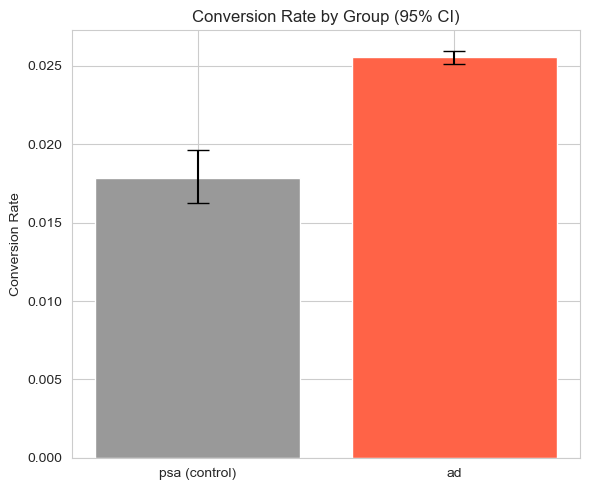

In [44]:
fig, ax = plt.subplots(figsize=(6, 5))
rates = [rate_psa, rate_ad]
errs = [
    [rate_psa - ci_psa[0], rate_ad - ci_ad[0]],
    [ci_psa[1] - rate_psa, ci_ad[1] - rate_ad]
]
ax.bar(['psa (control)', 'ad'], rates, yerr=errs, capsize=8, color=['#999999', '#FF6347'])
ax.set_ylabel('Conversion Rate')
ax.set_title('Conversion Rate by Group (95% CI)')
plt.tight_layout()
plt.show()

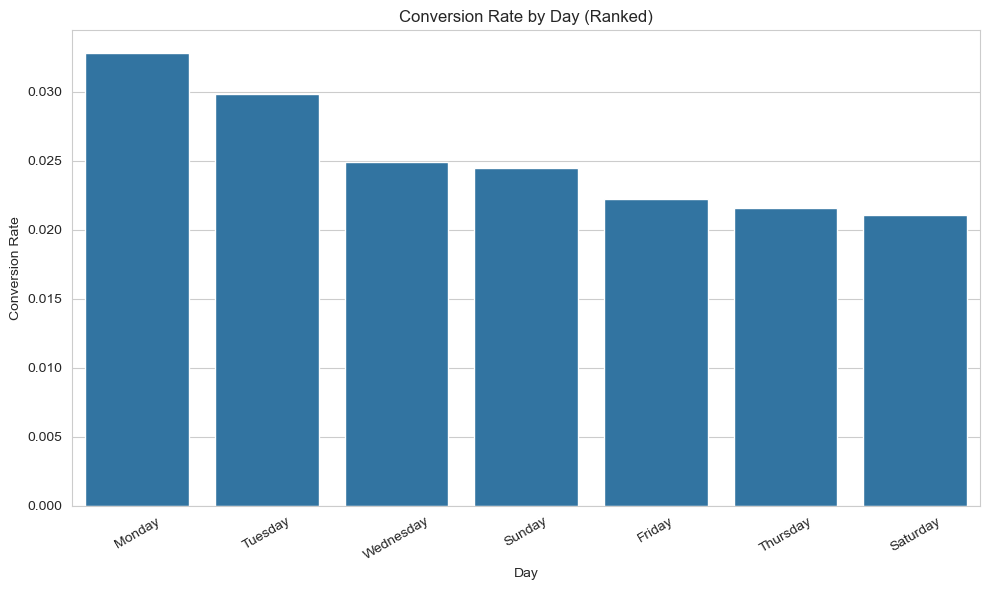

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(x=day_conv.index, y=day_conv['conversion_rate'], order=day_conv.index)
plt.title('Conversion Rate by Day (Ranked)')
plt.xlabel('Day')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

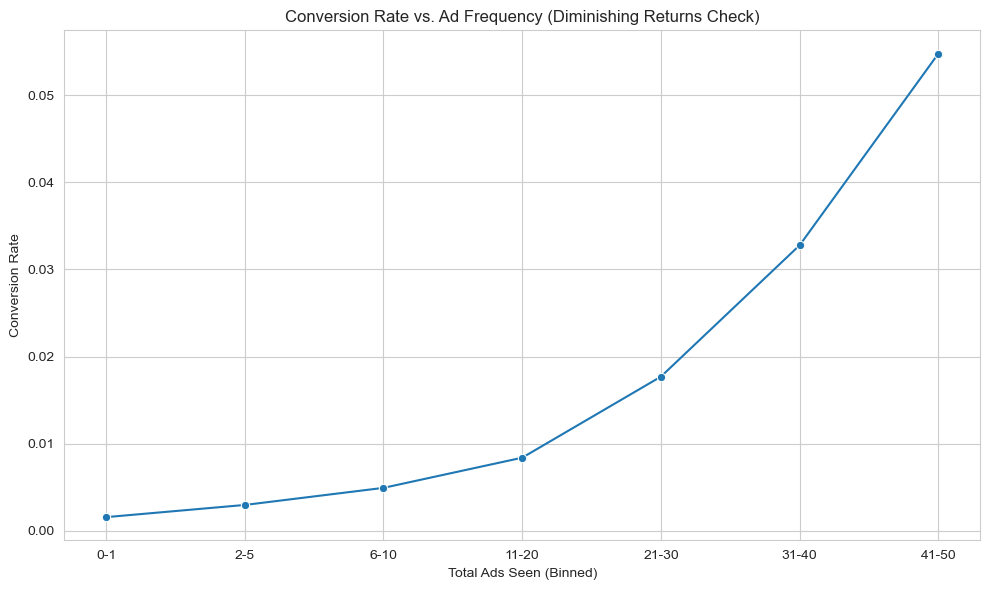

In [46]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=ads_conv.index, y=ads_conv['conversion_rate'], marker='o')
plt.title('Conversion Rate vs. Ad Frequency (Diminishing Returns Check)')
plt.xlabel('Total Ads Seen (Binned)')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

Users who saw the ad converted at 2.55%, versus 1.79% for users who saw the PSA. That's a 0.77 percentage point difference — about 4,343 extra conversions across the ad group. The confidence interval (0.60 to 0.94 points) stays well above zero, so this isn't just noise.

I can't say whether this is worth scaling up, because the dataset doesn't include what an ad impression actually costs.

Day and hour of exposure also showed statistically significant differences, but the actual size of the effect was tiny (eta-squared ≈ 0.0007) — not something worth building a targeting strategy around.

Users who saw more ads also converted more, and the gains kept growing rather than leveling off. But this probably isn't a real effect of frequency — more likely, users who were already more engaged just ended up seeing more ads. I wouldn't recommend increasing ad frequency based on this alone.